In [10]:
!pip install -qU langchain langchain-core langchain-mistralai langgraph python-dotenv

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_mistralai import ChatMistralAI
from typing import TypedDict
from dotenv import load_dotenv

In [4]:
from google.colab import userdata
import os

# Load secret from Colab Secrets
os.environ["MISTRAL_API_KEY"] = userdata.get("MISTRAL_API_KEY")

In [5]:
load_dotenv()

llm = ChatMistralAI(
    model="mistral-large-latest",
    temperature=0
)

In [6]:
class BlogType(TypedDict):
  title: str
  outline: str
  length_words: int
  content: str

In [7]:
def create_outline(state: BlogType) -> BlogType:
  title = state["title"]
  prompt = f"Create a detailed outline for the provide {title}"
  response = llm.invoke(prompt)
  state["outline"] = response
  return state

In [8]:
def create_content(state: BlogType) -> BlogType:
  outline = state["outline"]
  length_words = state["length_words"]
  prompt = f"Create a detailed blog content for the provide {outline} under {length_words} words"
  response = llm.invoke(prompt)
  state["content"] = response
  return state

In [9]:
#lets create our graph

graph = StateGraph(BlogType)

#add nodes
graph.add_node("create_outline", create_outline)
graph.add_node("create_content", create_content)

#add egdes
graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_content")
graph.add_edge("create_content", END)

workflow = graph.compile()

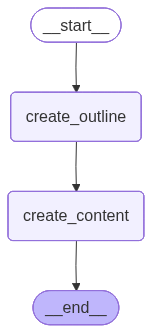

In [10]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [11]:
intial_state = {"title":"Rise of AI in Japan", "length_words": 300}

final_state = workflow.invoke(intial_state)

print(final_state['outline'])
print(final_state['content'])


content='# **Detailed Outline: The Rise of AI in Japan**\n\n## **I. Introduction**\n   A. **Overview of AI in Japan**\n      1. Definition of Artificial Intelligence (AI)\n      2. Japan’s unique relationship with technology and innovation\n      3. Importance of AI in Japan’s economic and societal development\n\n   B. **Historical Context**\n      1. Early adoption of robotics and automation (1970s–1990s)\n      2. Japan’s "Lost Decades" and the push for technological revival\n      3. Government and corporate initiatives in AI development\n\n   C. **Purpose of the Outline**\n      1. To explore Japan’s AI advancements\n      2. To analyze key industries and applications\n      3. To assess challenges and future prospects\n\n---\n\n## **II. Japan’s AI Ecosystem: Key Players and Policies**\n   A. **Government Initiatives and Policies**\n      1. **Japan’s AI Strategy (2017–Present)**\n         - "AI Technology Strategy" (2017)\n         - "Society 5.0" concept (integration of AI, IoT, 